# Topic 13: make_subplots() – creating custom subplot grids and placing traces

In [24]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [25]:
# loading a data set

tips = px.data.tips()
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


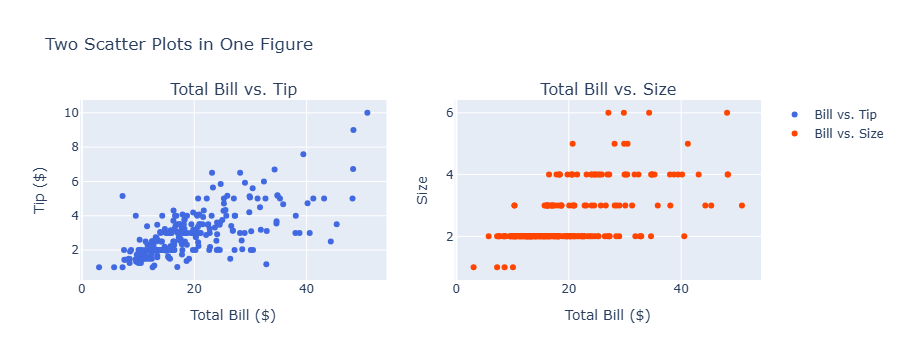

In [26]:
# create the grid
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[
                        'Total Bill vs. Tip',
                        'Total Bill vs. Size'])
# add scatte to panel 1,1
fig.add_trace(
    go.Scatter(
        x=tips['total_bill'], y=tips['tip'], 
        mode='markers', marker=dict(size=6, color='royalblue'),
        name='Bill vs. Tip'), 
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=tips['total_bill'], y=tips['size'], 
        mode='markers', marker=dict(size=6, color='orangered'),
        name='Bill vs. Size'), 
    row=1, col=2
)
# Update axes for each subplot
fig.update_xaxes(title_text='Total Bill ($)', row=1, col=1)
fig.update_xaxes(title_text='Total Bill ($)', row=1, col=2)
fig.update_yaxes(title_text='Tip ($)', row=1, col=1)
fig.update_yaxes(title_text='Size', row=1, col=2)

fig.update_layout(title='Two Scatter Plots in One Figure')
fig.show()

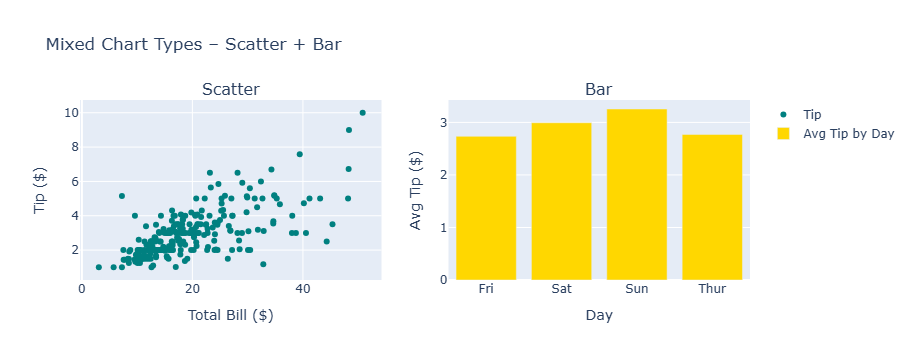

In [27]:
fig = make_subplots(rows=1, cols=2, subplot_titles=['Scatter', 'Bar'])

# Scatter in (1,1)
fig.add_trace(
    go.Scatter(x=tips['total_bill'], y=tips['tip'], mode='markers',
               marker=dict(size=6, color='teal'), name='Tip'),
    row=1, col=1
)

# Bar in (1,2) – pre‑aggregate
avg_tip = tips.groupby('day', as_index=False)['tip'].mean()
fig.add_trace(
    go.Bar(x=avg_tip['day'], y=avg_tip['tip'],
           marker=dict(color='gold'), name='Avg Tip by Day'),
    row=1, col=2
)

fig.update_xaxes(title_text='Total Bill ($)', row=1, col=1)
fig.update_xaxes(title_text='Day', row=1, col=2)
fig.update_yaxes(title_text='Tip ($)', row=1, col=1)
fig.update_yaxes(title_text='Avg Tip ($)', row=1, col=2)

fig.update_layout(title='Mixed Chart Types – Scatter + Bar')
fig.show()

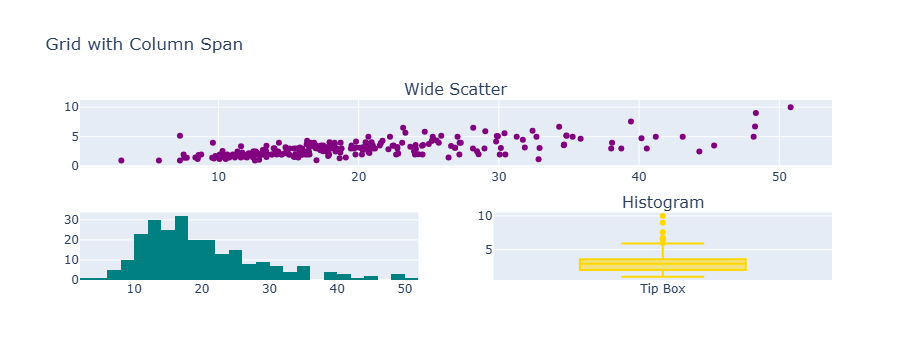

In [28]:
# row and col spans
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'colspan': 2}, None],   # top cell spans 2 columns
           [{}, {}]],                # bottom row: two separate cells
    subplot_titles=['Wide Scatter', None, 'Histogram', 'Boxplot']
)

# Wide scatter on top (row=1, col=1)
fig.add_trace(
    go.Scatter(x=tips['total_bill'], y=tips['tip'], mode='markers',
               marker=dict(size=6, color='purple'), name='Bill vs Tip'),
    row=1, col=1
)

# Histogram on bottom‑left (row=2, col=1)
fig.add_trace(
    go.Histogram(x=tips['total_bill'], marker=dict(color='teal'), name='Bill Dist'),
    row=2, col=1
)

# Box on bottom‑right (row=2, col=2)
fig.add_trace(
    go.Box(y=tips['tip'], marker=dict(color='gold'), name='Tip Box'),
    row=2, col=2
)

fig.update_layout(title='Grid with Column Span', showlegend=False)
fig.show()

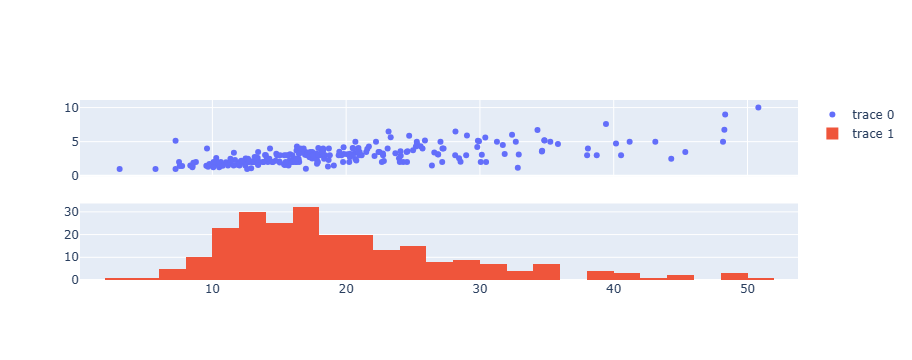

In [29]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True)
fig.add_trace(go.Scatter(x=tips['total_bill'], y=tips['tip'], mode='markers'), row=1, col=1)
fig.add_trace(go.Histogram(x=tips['total_bill']), row=2, col=1)
fig.show()

#  Practice Activity

In [30]:
tips = px.data.tips()

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


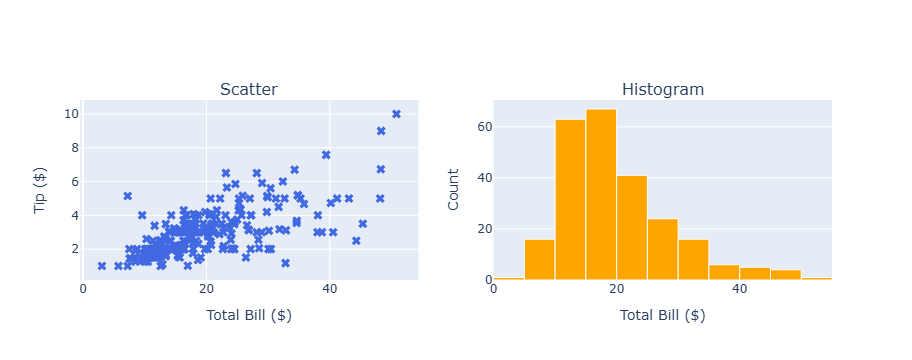

In [33]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Scatter', 'Histogram'],
    shared_xaxes=True
)

fig.add_trace(
    go.Scatter(
        x=tips['total_bill'],
        y=tips['tip'],
        mode='markers',
        marker=dict(size=8, color='royalblue', symbol='x'),
        showlegend=False 
    ),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(
        x=tips['total_bill'],
        nbinsx=20,
        marker=dict(color='orange', 
                    line=dict(color='white', width=1)),
        showlegend=False 
    ),
    row=1, col=2
)

fig.update_xaxes(title_text='Total Bill ($)', row=1, col=1)   # left x
fig.update_xaxes(title_text='Total Bill ($)', row=1, col=2)   # right x
fig.update_yaxes(title_text='Tip ($)', row=1, col=1)          # left y
fig.update_yaxes(title_text='Count', row=1, col=2)             # right y

fig.show()